In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import torch.utils.data as data


In [2]:
# device = torch.device("cuda")
device = torch.device("cpu")
# set_seed(42)

In [3]:
target_discrete_intervals = torch.tensor([100000, 350000]) # 0 to mniej niż 100k$, 1 pomiędzy, 2 więcej
validation_percent = 0.3 # Ile w walidacyjnym

categorical_columns = ["HallwayType", "HeatingType", "AptManageType", "TimeToBusStop", "TimeToSubway", "SubwayStation"]
columns_to_drop = []

### Ładowanie danych


Warto zparametryzować batch_size

Pewnie są dodatkowe parametry w data.DataLoader(...) które mogą nam pomóc


In [4]:
def Get_Train_Data():
    train_data = pd.read_csv("train_data.csv")
    train_data = train_data.drop(columns=columns_to_drop)
    return train_data

def Get_Train_Values(train_data):
    train_categorical = pd.get_dummies(train_data[categorical_columns]).astype(int)
    train_numerical = train_data.drop(columns=categorical_columns)
    return train_numerical, train_categorical


In [5]:
def Get_Final_Test_Data():
    final_test_data = pd.read_csv("test_data.csv", index_col=None)
    final_test_data = final_test_data.drop(columns=columns_to_drop)

    return final_test_data

In [6]:
def Get_Final_Test_Values(final_test_data):
    final_test_categorical = pd.get_dummies(final_test_data[categorical_columns]).astype(int)
    final_test_numerical = final_test_data.drop(columns=categorical_columns)
    return final_test_numerical, final_test_categorical

In [7]:
from matplotlib.pylab import size


def Get_Train_And_Validate_Loaders(train_numerical, train_categorical, size):
    train_indices = np.random.rand(size)>validation_percent
    print("Train data size: ", size)

    numerical_data = torch.from_numpy(train_numerical.values[train_indices, 1:]).float()
    categorical_data = torch.from_numpy(train_categorical.values[train_indices]).float()
    numerical_train_targets = torch.from_numpy(train_numerical.values[train_indices, 0]).float()
    discrete_train_targets = torch.bucketize(numerical_train_targets, target_discrete_intervals) # Dyskretne etykiety

    print(numerical_data.shape)
    print(categorical_data.shape)
    print(discrete_train_targets.shape)

    validate_numerical_data = torch.from_numpy(train_numerical.values[~train_indices, 1:]).float()
    validate_categorical_data = torch.from_numpy(train_categorical.values[~train_indices]).float()
    numerical_validate_targets = torch.from_numpy(train_numerical.values[~train_indices, 0]).float()
    discrete_validate_targets = torch.bucketize(numerical_validate_targets, target_discrete_intervals) # Dyskretne etykiety

    train_dataset = data.TensorDataset(numerical_data, categorical_data, discrete_train_targets)
    validate_dataset = data.TensorDataset(validate_numerical_data, validate_categorical_data, discrete_validate_targets)

    train_loader = data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    validate_loader = data.DataLoader(validate_dataset, batch_size=32, shuffle=False)

    return train_loader, validate_loader

In [8]:
def Get_Final_Test_Loader(final_test_numerical, final_test_categorical, size):
    print("Final test data size: ", size)

    final_test_numerical_data = torch.from_numpy(final_test_numerical.values).float()
    final_test_categorical_data = torch.from_numpy(final_test_categorical.values).float()

    final_test_dataset = data.TensorDataset(final_test_numerical_data, final_test_categorical_data)
    final_test_loader = data.DataLoader(final_test_dataset, shuffle=False)

    return final_test_loader

### Liczenie dokładności

In [9]:
def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct=(pred_targets.squeeze() == targets)[targets == i].sum() # tu zmieniłem żeby z tensorami działało
        accuracies.append(class_correct/(targets == i).sum())
    return(np.mean(accuracies))

In [10]:
def Get_Accuracy(model, data_loader, get_output_distribution=False):
    all_preds = torch.empty(0, dtype=torch.long, device=device)
    all_targets = torch.empty(0, dtype=torch.long, device=device)
    guesses_distribution = np.zeros(shape=[3])

    model.eval()
    with torch.no_grad():
        for x, cat_x, labels in data_loader:
            x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
            output = model(x, cat_x).squeeze()

            if len(output.shape) == 1:
                pred_ = output.max(0, keepdim=True)[1]
            else:
                pred_ = output.max(1, keepdim=True)[1]

            all_preds = torch.cat([all_preds, pred_])
            all_targets = torch.cat([all_targets, labels])
            out_dist =torch.nn.functional.one_hot(pred_).sum(dim=0)
            for L in range(out_dist.shape[1]):
                guesses_distribution[L] += out_dist.squeeze()[L]

    accuracy = calc_accuracy(all_preds, all_targets)
    if get_output_distribution:
        return accuracy, guesses_distribution
    else:
        return accuracy

#### Zapis do pliku


In [11]:
def Save_Final_Predictions_To_File(model, final_test_loader):
    model.eval()
    output_array = []
    with torch.no_grad():
        for x, cat_x in final_test_loader:
            x, cat_x = x.to(device), cat_x.to(device)
            # x = x.unsqueeze(0)
            # cat_x = cat_x.unsqueeze(0)

            out = model(x, cat_x).squeeze()
            pred_ = out.max(0, keepdim=True)[1]
            output_array.append(pred_.item())

    pd.Series(output_array).to_csv("pred.csv", index=False, header=False)


### Tworzenie DataLoaderów


In [12]:
train_data = Get_Train_Data()
train_numerical_values, train_categorical_values = Get_Train_Values(train_data)
train_loader, validate_loader = Get_Train_And_Validate_Loaders(train_numerical_values, train_categorical_values, len(train_data))

final_test_data= Get_Final_Test_Data()
final_test_numerical_values, final_test_categorical_values = Get_Final_Test_Values(final_test_data)
final_test_loader = Get_Final_Test_Loader(final_test_numerical_values, final_test_categorical_values, len(final_test_data))

Train data size:  4124
torch.Size([2854, 10])
torch.Size([2854, 23])
torch.Size([2854])
Final test data size:  1767


#### Badanie rozkładu klas


In [13]:
def Get_Class_Weights(weight_classes : bool):
    if not weight_classes:
        return torch.ones(size=[len(target_discrete_intervals)+1])
    check_train_data = Get_Train_Data()
    check_num, _ = Get_Train_Values(check_train_data)
    check_numerical_train_targets = torch.from_numpy(check_num.values[:, 0]).float()
    check_discrete_train_targets = torch.bucketize(check_numerical_train_targets, target_discrete_intervals) # Dyskretne etykiety
    check_out_dist = torch.nn.functional.one_hot(check_discrete_train_targets).sum(dim=0)
    print("Class distribution: ", check_out_dist)
    class_weights = torch.tensor([1.0/check_out_dist[0], 1.0/check_out_dist[1], 1.0/check_out_dist[2]])
    class_weights = class_weights / class_weights.sum()
    print(class_weights)
    return class_weights

Get_Class_Weights(True)

Class distribution:  tensor([ 562, 2992,  570])
tensor([0.4600, 0.0864, 0.4536])


tensor([0.4600, 0.0864, 0.4536])

In [14]:
input_size = train_numerical_values.shape[1] + train_categorical_values.shape[1] - 1
print(input_size)

33


### Trenowanie


In [15]:
class Price_classifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 40)
        self.norm1  = nn.LayerNorm(40)
        self.act_1  = nn.LeakyReLU()
        self.d1     = nn.Dropout(0.4)

        self.layer2 = nn.Linear(40, 20)
        self.norm2  = nn.LayerNorm(20)
        self.act_2  = nn.LeakyReLU()
        self.d2     = nn.Dropout(0.4)

        self.layer3 = nn.Linear(20, 3)

    def forward(self, x, cat_x):
        x = torch.cat([x, cat_x], dim=1)

        x = self.layer1(x)
        x = self.norm1(x)
        x = self.act_1(x)
        x = self.d1(x)

        x = self.layer2(x)
        x = self.norm2(x)
        x = self.act_2(x)
        x = self.d2(x)

        out = self.layer3(x)
        return out

In [16]:
# criterion = nn.CrossEntropyLoss()
# model = Price_classifier(input_size).to(device)
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

# iters = []
# losses = []
# train_acc = []
# val_acc = []
# for n in range(100):
#     epoch_losses = []
#     model.train()
#     for x, cat_x, labels in iter(train_loader):
#         optimizer.zero_grad()
#         x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
#         out = model(x, cat_x)
#         loss = criterion(out, labels)
#         loss.backward()
#         epoch_losses.append(loss.item())
#         optimizer.step()

#     loss_mean = np.array(epoch_losses).mean()
#     iters.append(n)
#     losses.append(loss_mean)
#     test_acc = Get_Accuracy(model, validate_loader)
#     print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")

#     train_acc.append(Get_Accuracy(model, train_loader)) # compute training accuracy
#     val_acc.append(test_acc)  # compute validation accuracy


# print("Final Training Accuracy: {}".format(train_acc[-1]))
# print("Final Validation Accuracy: {}".format(val_acc[-1]))

Class distribution:  tensor([ 562, 2992,  570])
tensor([0.4600, 0.0864, 0.4536])
Epoch 0 loss 1.029
Epoch 1 loss 0.670 val_acc: 0.642
Epoch 2 loss 0.575 val_acc: 0.787
Epoch 3 loss 0.544 val_acc: 0.775
Epoch 4 loss 0.567 val_acc: 0.811
Epoch 5 loss 0.530 val_acc: 0.785
Epoch 6 loss 0.511 val_acc: 0.848
Epoch 7 loss 0.538 val_acc: 0.838
Epoch 8 loss 0.515 val_acc: 0.850
Epoch 9 loss 0.525 val_acc: 0.840
Epoch 10 loss 0.498 val_acc: 0.840
Epoch 11 loss 0.401 val_acc: 0.843
Epoch 12 loss 0.399 val_acc: 0.842
Epoch 13 loss 0.398 val_acc: 0.840
Epoch 14 loss 0.431 val_acc: 0.841
Epoch 15 loss 0.427 val_acc: 0.836
Epoch 16 loss 0.435 val_acc: 0.839
Epoch 17 loss 0.448 val_acc: 0.859
Epoch 18 loss 0.445 val_acc: 0.850
Epoch 19 loss 0.459 val_acc: 0.858
Epoch 20 loss 0.459 val_acc: 0.858
Epoch 21 loss 0.366 val_acc: 0.846
Epoch 22 loss 0.381 val_acc: 0.871
Epoch 23 loss 0.384 val_acc: 0.852
Epoch 24 loss 0.402 val_acc: 0.859
Epoch 25 loss 0.418 val_acc: 0.859
Epoch 26 loss 0.416 val_acc: 0.872

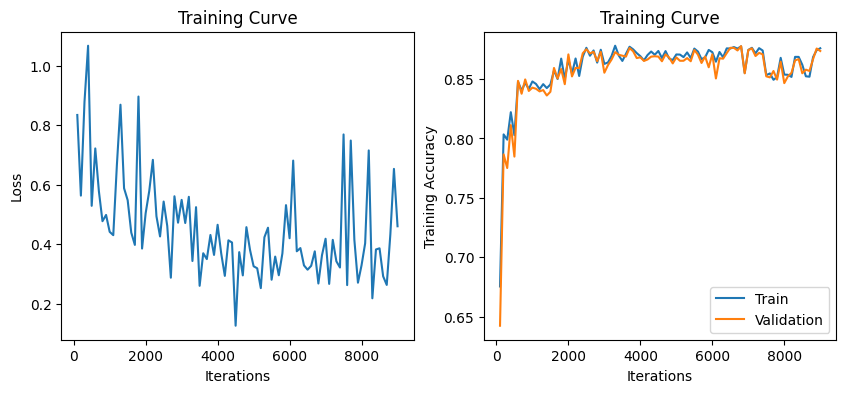

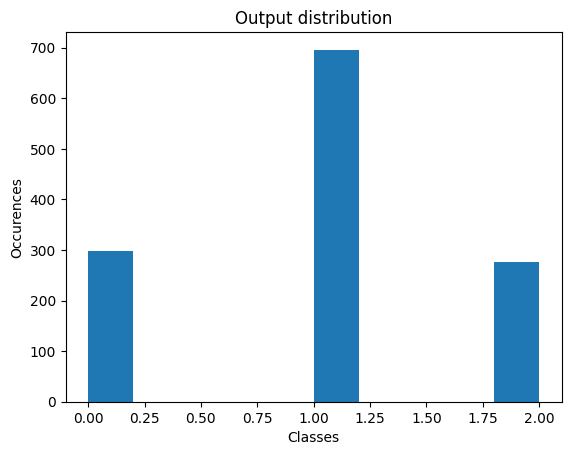

Final Training Accuracy: 0.8758177757263184
Final Validation Accuracy: 0.8735265731811523
Output distribution:  [298. 696. 276.]


In [18]:
def train(model,
          train_loader,
          validate_loader,
          device,
          num_epochs=100,
          lr=1e-3,
          weight_decay=1e-3,
          log_every=10,
          weight_classes=True,
          with_plot=True):

    criterion = nn.CrossEntropyLoss(weight=Get_Class_Weights(weight_classes))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    iters, losses, train_acc, val_acc = [], [], [], []
    idx = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []

        for x, cat_x, labels in iter(train_loader):
            x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(x, cat_x)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

            if idx % log_every == log_every - 1:
                iters.append(idx)
                losses.append(float(loss.item()))
                train_acc.append(Get_Accuracy(model, train_loader))
                val_acc.append(Get_Accuracy(model, validate_loader))
            idx += 1

        loss_mean = float(np.mean(epoch_losses)) if len(epoch_losses) else float("nan")
        if len(val_acc):
            print(f"Epoch {epoch} loss {loss_mean:.3f} val_acc: {val_acc[-1]:.3f}")
        else:
            print(f"Epoch {epoch} loss {loss_mean:.3f}")

    _, output_distribution = Get_Accuracy(model, validate_loader, get_output_distribution=True)

    if with_plot and len(iters):
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.title("Training Curve")
        plt.plot(iters, losses, label="Train")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")

        plt.subplot(1, 2, 2)
        plt.title("Training Curve")
        plt.plot(iters, train_acc, label="Train")
        plt.plot(iters, val_acc, label="Validation")
        plt.xlabel("Iterations")
        plt.ylabel("Training Accuracy")
        plt.legend(loc="best")

        plt.show()


        hist_distribution = np.repeat(np.arange(len(output_distribution)), output_distribution.astype(int))
        plt.hist(hist_distribution)
        plt.title("Output distribution")
        plt.xlabel("Classes")
        plt.ylabel("Occurences")

        plt.show()



    print("Final Training Accuracy: {}".format(train_acc[-1] if len(train_acc) else None))
    print("Final Validation Accuracy: {}".format(val_acc[-1] if len(val_acc) else None))
    print("Output distribution: ", output_distribution)

    return {
        "iters": iters,
        "losses": losses,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "model": model,
        "optimizer": optimizer,
        "criterion": criterion,
        "output_distribution": output_distribution,
    }

model = Price_classifier(input_size).to(device)

history = train(
    model=model,
    train_loader=train_loader,
    validate_loader=validate_loader,
    device=device,
    num_epochs=100,
    lr=0.001,
    weight_decay=0.0001,
    log_every=100,
    weight_classes=True,
    with_plot=True
)


In [19]:
save_to_file = True
if save_to_file:
    Save_Final_Predictions_To_File(model, final_test_loader)